In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42

In [3]:
DATA_PATH = Path('SouthGermanCredit.asc')

df = pd.read_csv(DATA_PATH, sep=r'\s+')
print('Розмір датасету:', df.shape)
df.head()

Розмір датасету: (1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


In [4]:
print('Кількість пропущених значень:', df.isna().sum().sum())
print('Кількість дублікатів:', df.duplicated().sum())
print()
print('Типи даних:')
print(df.dtypes.value_counts())

Кількість пропущених значень: 0
Кількість дублікатів: 0

Типи даних:
int64    21
Name: count, dtype: int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
laufkont,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
laufzeit,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
moral,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
verw,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
hoehe,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
sparkont,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
beszeit,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
famges,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
buerge,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0


In [6]:
target = df['kredit'].copy()
X_raw = df.drop(columns='kredit').copy()

numeric_columns = ['laufzeit', 'hoehe', 'alter']
categorical_columns = [c for c in X_raw.columns if c not in numeric_columns]

X_encoded = pd.get_dummies(
    X_raw,
    columns=categorical_columns,
    dtype=float
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
print('Кількість ознак до кодування:', X_raw.shape[1])
print('Кількість ознак після one-hot encoding:', X_encoded.shape[1])
print('Форма матриці для кластеризації:', X_scaled.shape)

Кількість ознак до кодування: 20
Кількість ознак після one-hot encoding: 71
Форма матриці для кластеризації: (1000, 71)


In [7]:
def evaluate_clustering(X, k_values=range(2, 9)):
    rows = []
    labels_storage = {}

    for k in k_values:
        models = {
            'K-Means': KMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=10
            ),
            'Agglomerative': AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
        }

        for model_name, model in models.items():
            labels = model.fit_predict(X)
            labels_storage[(model_name, k)] = labels

            rows.append({
                'model': model_name,
                'k': k,
                'silhouette': silhouette_score(X, labels, sample_size=min(500, len(X)), random_state=RANDOM_STATE),
                'calinski_harabasz': calinski_harabasz_score(X, labels),
                'davies_bouldin': davies_bouldin_score(X, labels)
            })

    return pd.DataFrame(rows), labels_storage


def add_total_rank(results):
    ranked = results.copy()
    ranked['rank_silhouette'] = ranked['silhouette'].rank(
        ascending=False, method='min'
    )
    ranked['rank_calinski'] = ranked['calinski_harabasz'].rank(
        ascending=False, method='min'
    )
    ranked['rank_davies'] = ranked['davies_bouldin'].rank(
        ascending=True, method='min'
    )
    ranked['total_rank'] = (
        ranked['rank_silhouette'] +
        ranked['rank_calinski'] +
        ranked['rank_davies']
    )
    return ranked.sort_values(['total_rank', 'model', 'k'])

In [8]:
full_results, full_labels = evaluate_clustering(X_scaled)
full_ranked = add_total_rank(full_results)
full_ranked.round(4)

,model,k,silhouette,calinski_harabasz,davies_bouldin,rank_silhouette,rank_calinski,rank_davies,total_rank
1,Agglomerative,2,0.1664,30.0064,1.9965,1.0,7.0,1.0,9.0
7,Agglomerative,5,0.0614,25.8277,2.9785,4.0,11.0,2.0,17.0
4,K-Means,4,0.0570,38.9919,3.4872,5.0,3.0,9.0,17.0
5,Agglomerative,4,0.0781,27.4264,3.3586,3.0,10.0,6.0,19.0
8,K-Means,6,0.0504,33.0980,3.4580,6.0,5.0,8.0,19.0
3,Agglomerative,3,0.0998,28.3268,3.4927,2.0,9.0,10.0,21.0
10,K-Means,7,0.0487,30.8783,3.3757,8.0,6.0,7.0,21.0
2,K-Means,3,0.0492,40.5167,4.0747,7.0,2.0,13.0,22.0
12,K-Means,8,0.0447,29.7731,3.1991,10.0,8.0,4.0,22.0
6,K-Means,5,0.0462,34.8765,3.5529,9.0,4.0,11.0,24.0


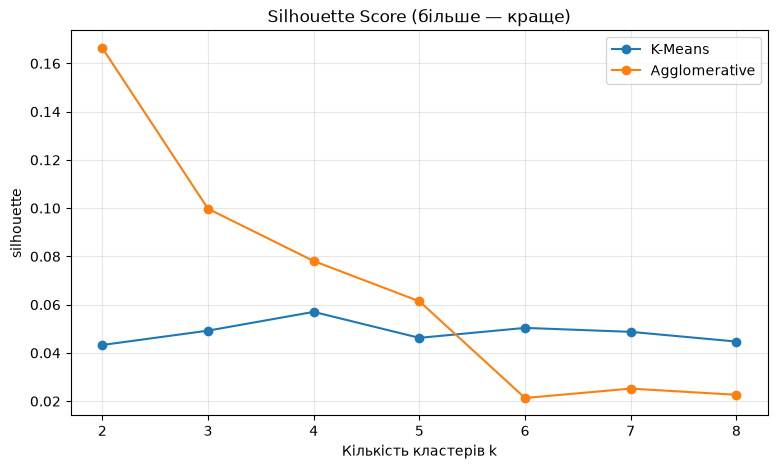

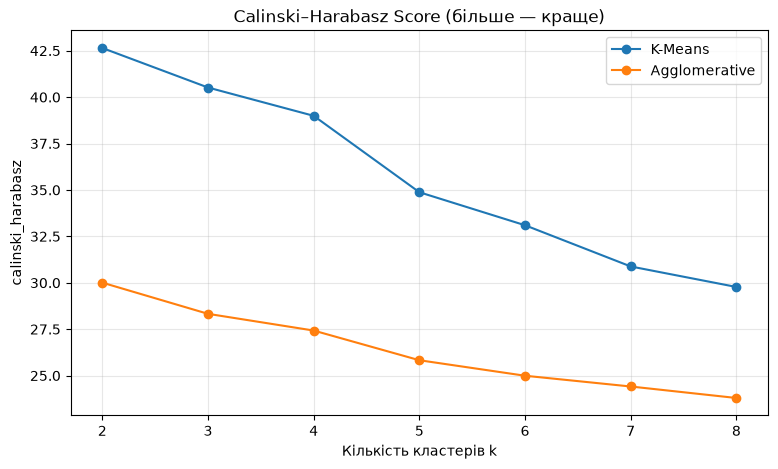

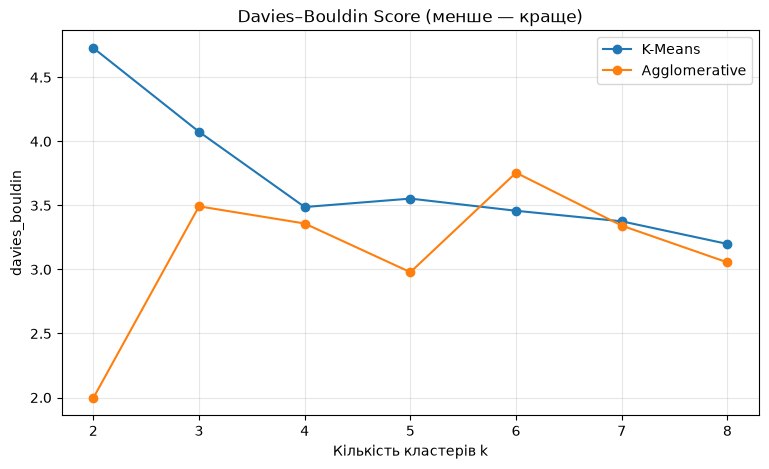

In [9]:
metrics = [
    ('silhouette', 'Silhouette Score (більше — краще)'),
    ('calinski_harabasz', 'Calinski–Harabasz Score (більше — краще)'),
    ('davies_bouldin', 'Davies–Bouldin Score (менше — краще)')
]

for metric, title in metrics:
    plt.figure(figsize=(9, 5))
    for model_name in full_results['model'].unique():
        part = full_results[full_results['model'] == model_name]
        plt.plot(part['k'], part[metric], marker='o', label=model_name)
    plt.title(title)
    plt.xlabel('Кількість кластерів k')
    plt.ylabel(metric)
    plt.xticks(range(2, 9))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [10]:
best_full = full_ranked.iloc[0]
best_full_model = best_full['model']
best_full_k = int(best_full['k'])
best_full_labels = full_labels[(best_full_model, best_full_k)]

print('Найкращий результат для повного датасету:')
print('Модель:', best_full_model)
print('Кількість кластерів:', best_full_k)
print('Silhouette:', round(best_full['silhouette'], 4))
print('Calinski-Harabasz:', round(best_full['calinski_harabasz'], 4))
print('Davies-Bouldin:', round(best_full['davies_bouldin'], 4))

Найкращий результат для повного датасету:
Модель: Agglomerative
Кількість кластерів: 2
Silhouette: 0.1664
Calinski-Harabasz: 30.0064
Davies-Bouldin: 1.9965


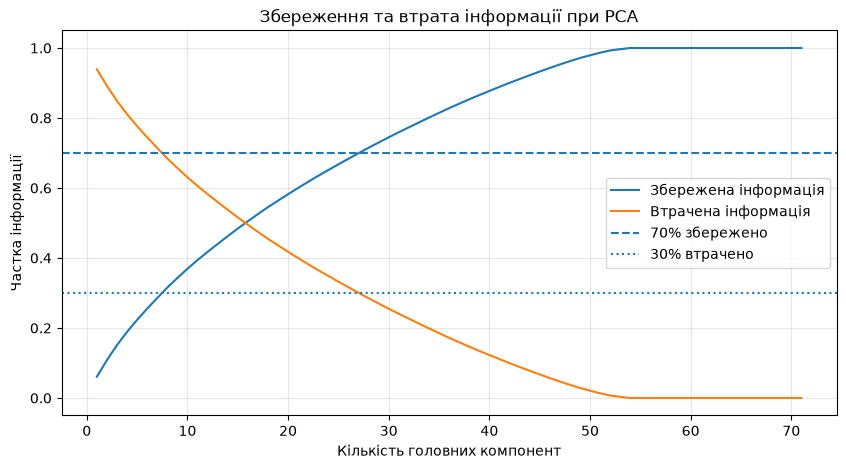

In [11]:
pca_all = PCA(random_state=RANDOM_STATE)
pca_all.fit(X_scaled)

cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
information_loss = 1 - cumulative_variance
component_numbers = np.arange(1, len(cumulative_variance) + 1)

plt.figure(figsize=(10, 5))
plt.plot(component_numbers, cumulative_variance, label='Збережена інформація')
plt.plot(component_numbers, information_loss, label='Втрачена інформація')
plt.axhline(0.70, linestyle='--', label='70% збережено')
plt.axhline(0.30, linestyle=':', label='30% втрачено')
plt.xlabel('Кількість головних компонент')
plt.ylabel('Частка інформації')
plt.title('Збереження та втрата інформації при PCA')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [12]:
n_components_70 = int(np.argmax(cumulative_variance >= 0.70) + 1)
retained_information = cumulative_variance[n_components_70 - 1]
actual_loss = 1 - retained_information

print('Початкова кількість ознак:', X_scaled.shape[1])
print('Кількість компонентів для збереження >= 70% інформації:', n_components_70)
print('Фактично збережено інформації:', f'{retained_information:.2%}')
print('Фактично втрачено інформації:', f'{actual_loss:.2%}')

Початкова кількість ознак: 71
Кількість компонентів для збереження >= 70% інформації: 28
Фактично збережено інформації: 71.50%
Фактично втрачено інформації: 28.50%


In [13]:
pca_70 = PCA(n_components=n_components_70, random_state=RANDOM_STATE)
X_pca_70 = pca_70.fit_transform(X_scaled)
print('Форма перетвореного датасету:', X_pca_70.shape)

Форма перетвореного датасету: (1000, 28)


In [14]:
pca_results, pca_labels = evaluate_clustering(X_pca_70)
pca_ranked = add_total_rank(pca_results)
pca_ranked.round(4)

,model,k,silhouette,calinski_harabasz,davies_bouldin,rank_silhouette,rank_calinski,rank_davies,total_rank
1,Agglomerative,2,0.2309,43.3775,1.7161,1.0,9.0,1.0,11.0
9,Agglomerative,6,0.0801,37.3105,2.4958,2.0,12.0,2.0,16.0
6,K-Means,5,0.0717,51.7013,2.8224,6.0,4.0,6.0,16.0
8,K-Means,6,0.0695,46.6220,2.7997,8.0,5.0,5.0,18.0
12,K-Means,8,0.0708,43.7063,2.6019,7.0,8.0,3.0,18.0
7,Agglomerative,5,0.0727,39.4564,2.6710,4.0,11.0,4.0,19.0
3,Agglomerative,3,0.0720,43.8320,3.0862,5.0,7.0,9.0,21.0
5,Agglomerative,4,0.0767,40.6384,2.9716,3.0,10.0,8.0,21.0
4,K-Means,4,0.0663,53.2124,3.1391,10.0,3.0,10.0,23.0
2,K-Means,3,0.0681,57.9998,3.4061,9.0,2.0,13.0,24.0


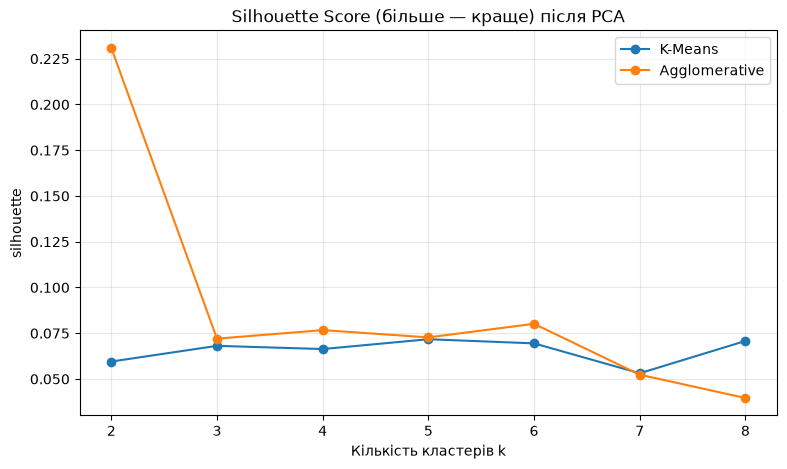

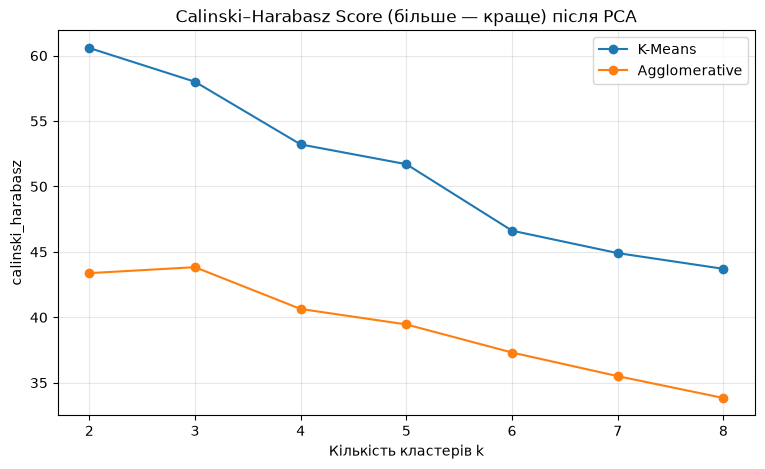

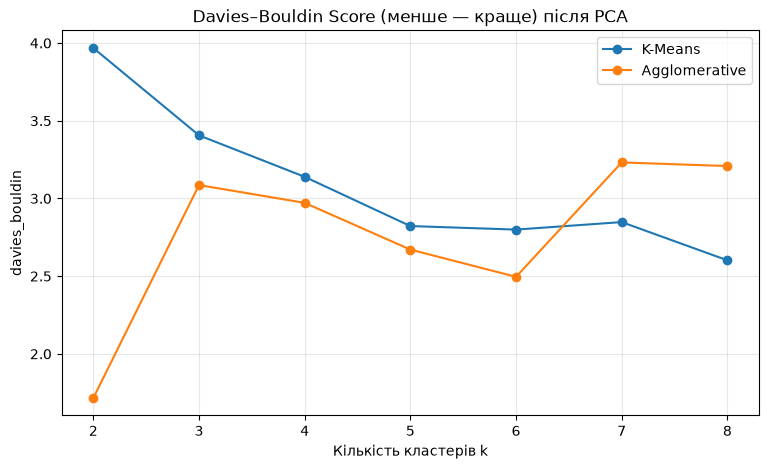

In [15]:
for metric, title in metrics:
    plt.figure(figsize=(9, 5))
    for model_name in pca_results['model'].unique():
        part = pca_results[pca_results['model'] == model_name]
        plt.plot(part['k'], part[metric], marker='o', label=model_name)
    plt.title(title + ' після PCA')
    plt.xlabel('Кількість кластерів k')
    plt.ylabel(metric)
    plt.xticks(range(2, 9))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [16]:
best_pca = pca_ranked.iloc[0]
best_pca_model = best_pca['model']
best_pca_k = int(best_pca['k'])
best_pca_labels = pca_labels[(best_pca_model, best_pca_k)]

print('Найкращий результат після PCA:')
print('Модель:', best_pca_model)
print('Кількість кластерів:', best_pca_k)
print('Silhouette:', round(best_pca['silhouette'], 4))
print('Calinski-Harabasz:', round(best_pca['calinski_harabasz'], 4))
print('Davies-Bouldin:', round(best_pca['davies_bouldin'], 4))

Найкращий результат після PCA:
Модель: Agglomerative
Кількість кластерів: 2
Silhouette: 0.2309
Calinski-Harabasz: 43.3775
Davies-Bouldin: 1.7161


In [17]:
comparison_rows = []

for model_name in ['K-Means', 'Agglomerative']:
    common_k = best_full_k
    labels_before = full_labels[(model_name, common_k)]
    labels_after = pca_labels[(model_name, common_k)]

    comparison_rows.append({
        'model': model_name,
        'k': common_k,
        'ARI_full_vs_PCA': adjusted_rand_score(labels_before, labels_after),
        'NMI_full_vs_PCA': normalized_mutual_info_score(labels_before, labels_after)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(4)

,model,k,ARI_full_vs_PCA,NMI_full_vs_PCA
0,K-Means,2,0.9682,0.9331
1,Agglomerative,2,0.9839,0.9586


In [18]:
best_partition_ari = adjusted_rand_score(best_full_labels, best_pca_labels)
best_partition_nmi = normalized_mutual_info_score(best_full_labels, best_pca_labels)

summary = pd.DataFrame({
    'dataset': ['Повний датасет', 'PCA (збережено >=70%)'],
    'best_model': [best_full_model, best_pca_model],
    'best_k': [best_full_k, best_pca_k],
    'silhouette': [best_full['silhouette'], best_pca['silhouette']],
    'calinski_harabasz': [best_full['calinski_harabasz'], best_pca['calinski_harabasz']],
    'davies_bouldin': [best_full['davies_bouldin'], best_pca['davies_bouldin']]
})

print('Порівняння найкращих конфігурацій:')
display(summary.round(4))
print('ARI між найкращими розбиттями:', round(best_partition_ari, 4))
print('NMI між найкращими розбиттями:', round(best_partition_nmi, 4))

Порівняння найкращих конфігурацій:


,dataset,best_model,best_k,silhouette,calinski_harabasz,davies_bouldin
0,Повний датасет,Agglomerative,2,0.1664,30.0064,1.9965
1,PCA (збережено >=70%),Agglomerative,2,0.2309,43.3775,1.7161


ARI між найкращими розбиттями: 0.9839
NMI між найкращими розбиттями: 0.9586


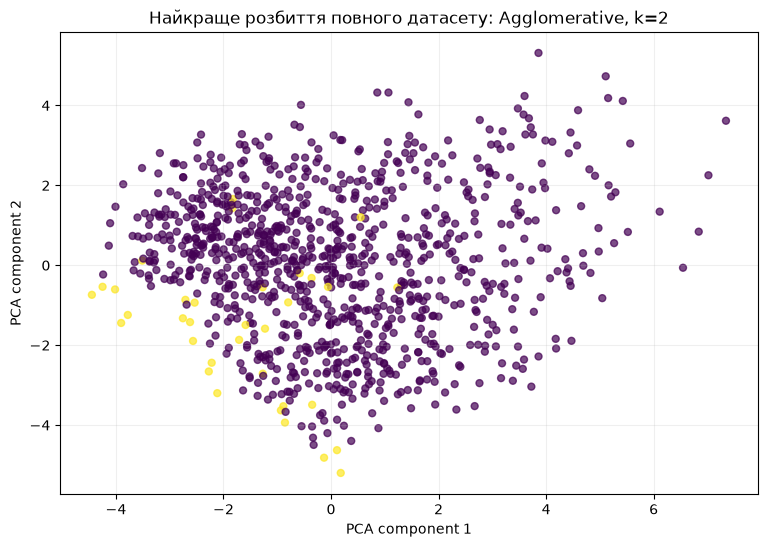

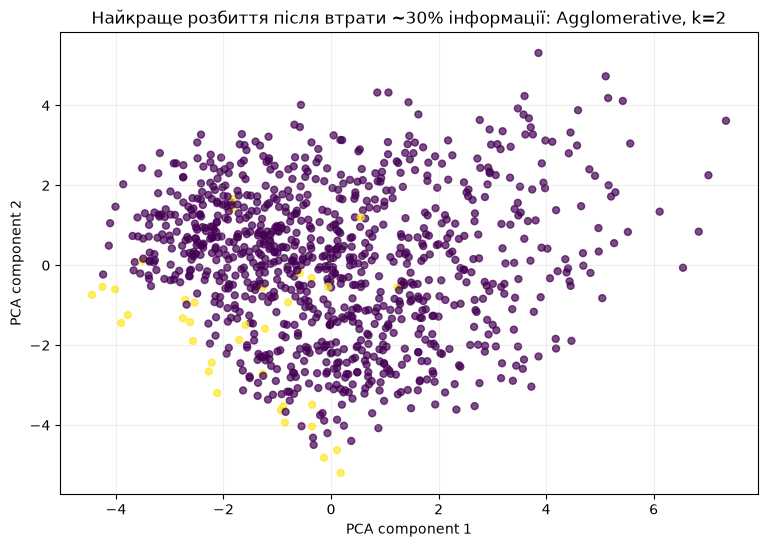

In [19]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_full_labels, s=25, alpha=0.7)
plt.title(f'Найкраще розбиття повного датасету: {best_full_model}, k={best_full_k}')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_pca_labels, s=25, alpha=0.7)
plt.title(f'Найкраще розбиття після втрати ~30% інформації: {best_pca_model}, k={best_pca_k}')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.grid(alpha=0.2)
plt.show()

In [20]:
external_comparison = pd.DataFrame({
    'variant': ['Повний датасет', 'PCA'],
    'ARI_with_credit_risk': [
        adjusted_rand_score(target, best_full_labels),
        adjusted_rand_score(target, best_pca_labels)
    ],
    'NMI_with_credit_risk': [
        normalized_mutual_info_score(target, best_full_labels),
        normalized_mutual_info_score(target, best_pca_labels)
    ]
})
external_comparison.round(4)

,variant,ARI_with_credit_risk,NMI_with_credit_risk
0,Повний датасет,-0.0241,0.0122
1,PCA,-0.0250,0.0129
